<a href="https://colab.research.google.com/github/Amdzak/PCVK-Tugas-Kelompok/blob/main/Kelompok_Machine_Learning(PCVK).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download dataset melalui kaggle

proses download tidak menggunakan koneksi internet probadi melainkan menggunakan sisi server collab jadi jangan khawatir dengan ukuran dataset yang bsear

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install kaggle
from google.colab import userdata
import os

try:
  os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
  os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
except Exception as e:
  print(e)

!kaggle datasets download -d moltean/fruits



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
fruits.zip: Skipping, found more recently modified local copy (use --force to force download)


Extract dataset

In [3]:
import zipfile
from tqdm import tqdm

zip_path = "fruits.zip"
extract_path = "fruits360"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    total_files = len(zip_ref.infolist())
    with tqdm(total=total_files, desc='Extracting') as pbar:
        for file in zip_ref.infolist():
            zip_ref.extract(file, extract_path)
            pbar.update(1)


Extracting: 100%|██████████| 286725/286725 [01:37<00:00, 2931.23it/s]


# **Proses Pra Pengolahan Data & Labeling**

## Pemetaan Ulang Label (Label Remapping): Memetakan 131 kelas asli (sub-folder) ke dalam 6 kategori target baru yang telah ditentukan

In [4]:
import os
import shutil

source_train = "/content/fruits360/fruits-360_100x100/fruits-360/Training"
source_test = "/content/fruits360/fruits-360_100x100/fruits-360/Test"

target_base = "./Remapped_Training/Kacang-Sitrus-Melon"

# Mapping kategori → nama folder buah
category_map = {
    "Kacang-Sitrus-Melon": [
        # Kacang
        "Caju seed", "Chestnut", "Cocos", "Hazelnut",
        "Nut", "Nut Forest", "Nut Pecan", "Pistachio", "Walnut",

        # Sitrus
        "Clementine", "Grapefruit Pink", "Grapefruit White",
        "Kumquats", "Lemon", "Lemon Meyer", "Limes",
        "Mandarine", "Orange", "Pomelo Sweetie", "Tangelo",

        # Melon
        "Cantaloupe", "Melon Piel de Sapo"
    ]
}

def find_fruit_class(folder):
    for fruit in category_map["Kacang-Sitrus-Melon"]:
        if folder.startswith(fruit):
            return fruit
    return None

# Membuat folder train/test
train_target = os.path.join(target_base, "Train")
test_target  = os.path.join(target_base, "Test")
os.makedirs(train_target, exist_ok=True)
os.makedirs(test_target, exist_ok=True)

# --- PROSES TRAIN ---
for folder in os.listdir(source_train):
    fruit = find_fruit_class(folder)
    if fruit is None:
        continue

    src_folder = os.path.join(source_train, folder)
    dst_folder = os.path.join(train_target, fruit)
    os.makedirs(dst_folder, exist_ok=True)

    for img in os.listdir(src_folder):
        shutil.copy2(os.path.join(src_folder, img), os.path.join(dst_folder, img))

# --- PROSES TEST ---
for folder in os.listdir(source_test):
    fruit = find_fruit_class(folder)
    if fruit is None:
        continue

    src_folder = os.path.join(source_test, folder)
    dst_folder = os.path.join(test_target, fruit)
    os.makedirs(dst_folder, exist_ok=True)

    for img in os.listdir(src_folder):
        shutil.copy2(os.path.join(src_folder, img), os.path.join(dst_folder, img))

print("DONE! Struktur Train/Test per buah berhasil dibuat.")


DONE! Struktur Train/Test per buah berhasil dibuat.


## Scaling/Normalisasi: Mengubah rentang nilai piksel (misal: dari 0-255 menjadi 0-1) agar seragam.

In [5]:
import os
import cv2
import numpy as np

dataset_dir = "/content/Remapped_Training/Kacang-Sitrus-Melon/Train"

images = []
labels = []

# loop setiap folder kelas
for class_name in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_name)

    # kalau bukan folder, skip
    if not os.path.isdir(class_path):
        continue

    # loop setiap gambar dalam folder kelas
    for file in os.listdir(class_path):
        img_path = os.path.join(class_path, file)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # NORMALISASI
        img = img.astype("float32") / 255.0

        images.append(img)
        labels.append(class_name)

X = np.array(images)
y = np.array(labels)

print("Shape data :", X.shape)
print("Min :", X.min())
print("Max :", X.max())

Shape data : (10425, 100, 100, 3)
Min : 0.0
Max : 1.0


Hasil Output sebelum dan sesudah melakukan scaling/normalisasi

In [6]:
# ambil 1 contoh gambar dari folder untuk BEFORE
sample_class = os.listdir(dataset_dir)[0]
sample_folder = os.path.join(dataset_dir, sample_class)
sample_file = os.listdir(sample_folder)[0]
sample_path = os.path.join(sample_folder, sample_file)

# BEFORE normalisasi
before_img = cv2.imread(sample_path)
before_img = cv2.cvtColor(before_img, cv2.COLOR_BGR2RGB)
before_img = cv2.resize(before_img, (100, 100))

print("Contoh nilai piksel sebelum Normalisasi (0–255):")
print(before_img[0:2, 0:3])

print("\nContoh nilai piksel setelah Normalisasi (0–1):")
print(img[0:2, 0:3])


Contoh nilai piksel sebelum Normalisasi (0–255):
[[[250 255 248]
  [253 255 249]
  [255 255 251]]

 [[251 255 252]
  [253 255 252]
  [255 254 252]]]

Contoh nilai piksel setelah Normalisasi (0–1):
[[[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]]


# **Proses Ekstraksi Fitur**

## Wajib mengekstraksi fitur yang relevan dari citra. Menggunakan piksel mentah (100x100x3) tidak disarankan untuk model non-DL.

### Ekstraksi Fitur Warna (HSV)

In [7]:
# === EKSTRAKSI FITUR WARNA HSV HISTOGRAM ===

def extract_hsv_histogram(image, bins=16):
    # convert RGB -> HSV
    hsv = cv2.cvtColor((image * 255).astype("uint8"), cv2.COLOR_RGB2HSV)

    # histogram untuk masing-masing channel
    hist_h = cv2.calcHist([hsv], [0], None, [bins], [0, 180])
    hist_s = cv2.calcHist([hsv], [1], None, [bins], [0, 256])
    hist_v = cv2.calcHist([hsv], [2], None, [bins], [0, 256])

    # normalisasi histogram
    hist_h = cv2.normalize(hist_h, hist_h).flatten()
    hist_s = cv2.normalize(hist_s, hist_s).flatten()
    hist_v = cv2.normalize(hist_v, hist_v).flatten()

    # gabungkan semua histogram
    feature_vector = np.hstack([hist_h, hist_s, hist_v])

    return feature_vector


# proses ekstraksi fitur dari X (yang sudah kamu normalisasi)
X_color_features = []

for img in X:
    fitur = extract_hsv_histogram(img)
    X_color_features.append(fitur)

X_color_features = np.array(X_color_features)

print("HSV Features shape:", X_color_features.shape)


HSV Features shape: (10425, 48)


### Ekstraksi Fitur Tekstur (LBP)

In [8]:
from skimage.feature import local_binary_pattern
import numpy as np
import cv2

# fungsi LBP (aman)
def extract_lbp_features(gray_img_uint8, radius=3):
    n_points = 8 * radius

    # LBP harus pakai uint8 → aman, tanpa warning
    lbp = local_binary_pattern(gray_img_uint8, n_points, radius, method='uniform')

    # histogram LBP
    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2)
    )

    # normalisasi histogram (ini aman)
    hist = hist.astype("float32")
    hist /= hist.sum()

    return hist

# === EKSTRAKSI FITUR TEKSTUR DARI X ===
X_texture_features = []

for img in X:
    # convert RGB normalized (0–1) → RGB 0–255
    img_uint8 = (img * 255).astype('uint8')

    # convert ke grayscale uint8 (no warning)
    gray_uint8 = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    # ekstraksi fitur tekstur LBP
    fitur_lbp = extract_lbp_features(gray_uint8)
    X_texture_features.append(fitur_lbp)

X_texture_features = np.array(X_texture_features)

print("LBP Features shape:", X_texture_features.shape)


LBP Features shape: (10425, 26)


### Ekstraksi Fitur Gray Level Co-occurrence Matrix

In [9]:
import numpy as np
import cv2
from skimage.feature import graycomatrix, graycoprops

def extract_glcm_features_from_uint8_image(gray_uint8, levels, distances, angles, props):
    # Quantize to `levels` (0..levels-1)
    if levels < 2 or levels > 256:
        raise ValueError("levels must be between 2 and 256")

    # use integer division for speed: 256//levels is bin width (assume divides 256)
    bin_width = 256 // levels
    if bin_width == 0:
        bin_width = 1
    quant = (gray_uint8 // bin_width).astype('uint8')

    # Ensure max value < levels
    quant[quant >= levels] = levels - 1

    # compute GLCM (symmetric, normalized)
    glcm = graycomatrix(quant, distances=distances, angles=angles, levels=levels, symmetric=True, normed=True)

    feats = []
    for p in props:
        arr = graycoprops(glcm, prop=p)  # shape: (len(distances), len(angles))
        # average over distances and angles
        feats.append(arr.mean())
    return np.array(feats, dtype="float32")


# === Batch extraction for dataset X (RGB normalized) ===
levels = 64
distances = (1,)  # keep small for speed; can add (1,2) if you have time
angles = (0, np.pi/4, np.pi/2, 3*np.pi/4)  # 4 angles averaged
props = ("contrast", "correlation", "energy", "homogeneity")

X_glcm_features = []
N = len(X)
print("Starting GLCM extraction for", N, "images. This may take a little while...")

for idx, img in enumerate(X):
    # convert normalized RGB (0-1) -> uint8 RGB (0-255)
    img_uint8 = (img * 255).astype('uint8')

    # convert to grayscale uint8
    gray_uint8 = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    # extract glcm features
    feats = extract_glcm_features_from_uint8_image(gray_uint8, levels=levels, distances=distances, angles=angles, props=props)

    X_glcm_features.append(feats)

    # progress print (very lightweight)
    if (idx + 1) % 500 == 0 or (idx + 1) == N:
        print(f"  processed {idx+1}/{N} images")

X_glcm_features = np.array(X_glcm_features, dtype="float32")
print("GLCM Features shape:", X_glcm_features.shape)


Starting GLCM extraction for 10425 images. This may take a little while...
  processed 500/10425 images
  processed 1000/10425 images
  processed 1500/10425 images
  processed 2000/10425 images
  processed 2500/10425 images
  processed 3000/10425 images
  processed 3500/10425 images
  processed 4000/10425 images
  processed 4500/10425 images
  processed 5000/10425 images
  processed 5500/10425 images
  processed 6000/10425 images
  processed 6500/10425 images
  processed 7000/10425 images
  processed 7500/10425 images
  processed 8000/10425 images
  processed 8500/10425 images
  processed 9000/10425 images
  processed 9500/10425 images
  processed 10000/10425 images
  processed 10425/10425 images
GLCM Features shape: (10425, 4)


### Ektraksi Fitur Bentuk Canny Edge Detection

In [10]:
import numpy as np
import cv2

def shape_features_from_uint8_image(img_uint8, canny_thresh1, canny_thresh2, min_contour_area):
    # if RGB, convert to gray
    if img_uint8.ndim == 3:
        gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    else:
        gray = img_uint8

    # --- Canny edge
    edges = cv2.Canny(gray, canny_thresh1, canny_thresh2)

    # edge density
    edge_density = edges.sum() / (edges.shape[0] * edges.shape[1])

    # find contours from edges (use RETR_EXTERNAL for speed)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # filter small contours
    big_contours = [c for c in contours if cv2.contourArea(c) >= min_contour_area]
    n_contours = len(big_contours)

    # initialize stats
    areas = []
    perimeters = []
    solidities = []
    aspect_ratios = []

    for c in big_contours:
        area = cv2.contourArea(c)
        perim = cv2.arcLength(c, True)
        if area <= 0:
            continue
        # bounding box aspect ratio
        x,y,w,h = cv2.boundingRect(c)
        aspect = float(w) / (h+1e-6)
        # convex hull for solidity
        hull = cv2.convexHull(c)
        hull_area = cv2.contourArea(hull)
        solidity = float(area) / (hull_area+1e-6)

        areas.append(area)
        perimeters.append(perim)
        solidities.append(solidity)
        aspect_ratios.append(aspect)

    # safe averages (if no contours -> zeros)
    if len(areas) == 0:
        mean_area = 0.0
        mean_perim = 0.0
        mean_solidity = 0.0
        mean_aspect = 0.0
    else:
        mean_area = float(np.mean(areas))
        mean_perim = float(np.mean(perimeters))
        mean_solidity = float(np.mean(solidities))
        mean_aspect = float(np.mean(aspect_ratios))

    # Hu moments (log scaled for stability)
    moments = cv2.moments(gray)
    hu = cv2.HuMoments(moments).flatten()  # 7 values
    # log transform (signed)
    with np.errstate(divide='ignore'):
        hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)

    feat = np.hstack([
        edge_density,
        n_contours,
        mean_area,
        mean_perim,
        mean_solidity,
        mean_aspect,
        hu_log   # 7
    ]).astype("float32")

    return feat

# === Batch extraction dari X (RGB normalized 0-1) ===
X_shape_features = []
N = len(X)
print("Starting shape feature extraction for", N, "images...")

for idx, img in enumerate(X):
    # convert normalized RGB -> uint8
    img_u8 = (img * 255).astype('uint8')
    feats = shape_features_from_uint8_image(img_u8, canny_thresh1=100, canny_thresh2=200, min_contour_area=10)
    X_shape_features.append(feats)

    # print progress ringan
    if (idx + 1) % 500 == 0 or (idx + 1) == N:
        print(f"  processed {idx+1}/{N} images")

X_shape_features = np.array(X_shape_features, dtype="float32")
print("Shape features shape:", X_shape_features.shape)


Starting shape feature extraction for 10425 images...
  processed 500/10425 images
  processed 1000/10425 images
  processed 1500/10425 images
  processed 2000/10425 images
  processed 2500/10425 images
  processed 3000/10425 images
  processed 3500/10425 images
  processed 4000/10425 images
  processed 4500/10425 images
  processed 5000/10425 images
  processed 5500/10425 images
  processed 6000/10425 images
  processed 6500/10425 images
  processed 7000/10425 images
  processed 7500/10425 images
  processed 8000/10425 images
  processed 8500/10425 images
  processed 9000/10425 images
  processed 9500/10425 images
  processed 10000/10425 images
  processed 10425/10425 images
Shape features shape: (10425, 13)


# **Reduksi Dimensi**

## Disarankan melakukan reduksi dimensi (misal: PCA - Principal Component Analysis) setelah ekstraksi fitur untuk mengurangi beban komputasi.

menggabungkan fitur menjadi 1

In [11]:
# gabungkan fitur warna + tekstur
X_combined = np.hstack([X_color_features, X_texture_features, X_glcm_features, X_shape_features])

print("Combined feature shape:", X_combined.shape)


Combined feature shape: (10425, 91)


### StandartScaler

Diperlukan supaya tidak ada data yang skalanya lebih besar

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

print("Scaled feature shape:", X_scaled.shape)

Scaled feature shape: (10425, 91)


Menentukan n_components yang diperlukan untuk Menjaga variansi data sebanyak mungkin sambil mengurangi dimensi.

In [13]:
from sklearn.decomposition import PCA
import numpy as np

pca_test = PCA().fit(X_scaled)

explained = np.cumsum(pca_test.explained_variance_ratio_)

optimal = np.argmax(explained >= 0.99) + 1

# print 80 komponen pertama
for i in range(1, 81):
    print(f"Komponen {i}: {explained[i-1]*100:.2f}% variansi tercapture")


Komponen 1: 20.31% variansi tercapture
Komponen 2: 36.89% variansi tercapture
Komponen 3: 47.36% variansi tercapture
Komponen 4: 54.71% variansi tercapture
Komponen 5: 60.85% variansi tercapture
Komponen 6: 65.57% variansi tercapture
Komponen 7: 69.06% variansi tercapture
Komponen 8: 72.10% variansi tercapture
Komponen 9: 74.49% variansi tercapture
Komponen 10: 76.66% variansi tercapture
Komponen 11: 78.74% variansi tercapture
Komponen 12: 80.61% variansi tercapture
Komponen 13: 82.11% variansi tercapture
Komponen 14: 83.54% variansi tercapture
Komponen 15: 84.81% variansi tercapture
Komponen 16: 85.89% variansi tercapture
Komponen 17: 86.91% variansi tercapture
Komponen 18: 87.88% variansi tercapture
Komponen 19: 88.79% variansi tercapture
Komponen 20: 89.58% variansi tercapture
Komponen 21: 90.32% variansi tercapture
Komponen 22: 90.95% variansi tercapture
Komponen 23: 91.53% variansi tercapture
Komponen 24: 92.04% variansi tercapture
Komponen 25: 92.51% variansi tercapture
Komponen 

menggunakan n_component = 61 karena udah mencover 99.99% data penting

In [14]:
from sklearn.decomposition import PCA

# pakai PCA dengan 61 komponen
pca = PCA(n_components=61)

# fit + transform dataset gabungan (warna + tekstur)
X_pca = pca.fit_transform(X_scaled)

print("Shape PCA:", X_pca.shape)

# cek variansi yang diambil oleh 61 komponen
print("Total Explained Variance:", pca.explained_variance_ratio_.sum())


Shape PCA: (10425, 61)
Total Explained Variance: 0.99063206


# Pembuatan Data Latih dan Data Uji

In [15]:
from sklearn.model_selection import train_test_split

# X_pca = fitur yg sudah kamu PCA 61 komponen
# y     = label kelas buah (kategori)

X_train, X_val, y_train, y_val = train_test_split(
    X_pca, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape :", X_val.shape)


Train shape: (8340, 61)
Test shape : (2085, 61)


# Pembuatan Model

import library

In [16]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
import joblib


Pencarian parameter terbaik untuk SVM

In [17]:
param_grid = {
    'C': [1, 10, 100],          # Coba C santai sampai C ketat
    'gamma': ['scale', 'auto'], # Cara hitung jarak
    'kernel': ['rbf']           # RBF biasanya paling ampuh buat gambar
}

# --- 3. TRAINING DENGAN GRID SEARCH ---
print("Sedang melatih SVM dan mencari parameter terbaik...")

svm = SVC()
grid_search = GridSearchCV(svm, param_grid, cv=5, verbose=2, n_jobs=-1)
# n_jobs=-1 artinya pakai semua core CPU biar ngebut

grid_search.fit(X_train, y_train)

# --- 4. HASIL TERBAIK ---
print("\n=== TRAINING SELESAI ===")
print(f"Parameter Terbaik: {grid_search.best_params_}")
print(f"Akurasi Training Terbaik (Validation): {grid_search.best_score_:.4f}")

# Simpan model terbaik ke variabel
best_svm = grid_search.best_estimator_

Sedang melatih SVM dan mencari parameter terbaik...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

=== TRAINING SELESAI ===
Parameter Terbaik: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Akurasi Training Terbaik (Validation): 0.9999


pembuatan model SVM berdasarkan parameter terbaik

In [18]:
# Model final pakai hyperparameter terbaik (dari cross-val)
svm_final = SVC(
    kernel='rbf',
    C=1,
    gamma='auto',
)

# Latih di seluruh data train (setelah PCA)
svm_final.fit(X_train, y_train)

SVC(C=1, gamma='auto')

penyimpanan model svm

In [19]:
import os

# Define the path within your mounted Google Drive
folder_path = '/content/drive/MyDrive/Machine Learning/Models/'

# Create the folder
os.makedirs(folder_path, exist_ok=True)

# Simpan Model SVM Terbaik
joblib.dump(svm_final, '/content/drive/MyDrive/Machine Learning/Models/model_svm_kacang_sitrus_melon.pkl')

print("Model berhasil disimpan!")

Model berhasil disimpan!


# Evaluasi Model

Ambil data dari folder test

In [20]:
import os
import cv2
import numpy as np

dataset_dir = "/content/Remapped_Training/Kacang-Sitrus-Melon/Test"

X_test_raw = []
y_test_raw = []

# loop setiap folder kelas
for class_name in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_name)

    # kalau bukan folder, skip
    if not os.path.isdir(class_path):
        continue

    # loop setiap gambar dalam folder kelas
    for file in os.listdir(class_path):
        img_path = os.path.join(class_path, file)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # NORMALISASI (0-1 float32)
        img_norm = img.astype("float32") / 255.0

        # Konversi ke uint8 RGB (0-255) untuk ekstraksi fitur LBP, GLCM, dan Shape
        img_uint8 = (img_norm * 255).astype('uint8')

        # Konversi ke grayscale uint8 (0-255) untuk ekstraksi fitur LBP dan GLCM
        gray_uint8 = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

        # extract feature using function above
        f_hsv = extract_hsv_histogram(img_norm)
        f_lbp = extract_lbp_features(gray_uint8)
        f_glcm = extract_glcm_features_from_uint8_image(gray_uint8, levels=64, distances=(1,), angles=(0, np.pi/4, np.pi/2, 3*np.pi/4), props=("contrast", "correlation", "energy", "homogeneity"))
        f_shape = shape_features_from_uint8_image(img_uint8, canny_thresh1=100, canny_thresh2=200, min_contour_area=10)

        # merge all feature
        feature_vector = np.hstack([f_hsv, f_lbp, f_glcm, f_shape])

        # append to raw
        X_test_raw.append(feature_vector)
        y_test_raw.append(class_name)

X_test_raw = np.array(X_test_raw)
y_test_raw = np.array(y_test_raw)

print(f"Selesai! Shape Data Test: {X_test_raw.shape}")

Selesai! Shape Data Test: (3779, 91)


Lakukan skala PCA

In [21]:
X_test_scaled = scaler.transform(X_test_raw)

X_test_pca = pca.transform(X_test_scaled)

print(f"Shape setelah PCA: {X_test_pca.shape}")

Shape setelah PCA: (3779, 61)


Hasil Evaluasi matriks

In [22]:
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# Lakukan Prediksi
y_pred_test = svm_final.predict(X_test_pca)

# Hitung Metriks Utama
acc = accuracy_score(y_test_raw, y_pred_test)
precision, recall, f1, _ = precision_recall_fscore_support(y_test_raw, y_pred_test, average='weighted')

print(f"\n=== HASIL EVALUASI DATA TEST ===")
print(f"Akurasi Total : {acc*100:.2f}%")
print(f"Precision (Weighted): {precision*100:.2f}%")
print(f"Recall (Weighted)   : {recall*100:.2f}%")
print(f"F1-Score (Weighted) : {f1*100:.2f}%")

print("\n--- Detail per Kelas ---")
report_dict = classification_report(y_test_raw, y_pred_test, output_dict=True)
print(classification_report(y_test_raw, y_pred_test))


=== HASIL EVALUASI DATA TEST ===
Akurasi Total : 99.42%
Precision (Weighted): 99.48%
Recall (Weighted)   : 99.42%
F1-Score (Weighted) : 99.43%

--- Detail per Kelas ---
                    precision    recall  f1-score   support

         Caju seed       1.00      1.00      1.00        75
        Cantaloupe       1.00      1.00      1.00       320
          Chestnut       0.88      1.00      0.94       153
        Clementine       1.00      1.00      1.00       166
             Cocos       1.00      0.99      1.00       166
   Grapefruit Pink       1.00      1.00      1.00       166
  Grapefruit White       1.00      1.00      1.00       164
          Hazelnut       1.00      1.00      1.00       157
          Kumquats       1.00      1.00      1.00       166
             Lemon       1.00      1.00      1.00       251
             Limes       1.00      1.00      1.00       166
         Mandarine       1.00      1.00      1.00       166
Melon Piel de Sapo       1.00      1.00      1.00

convusion matriks

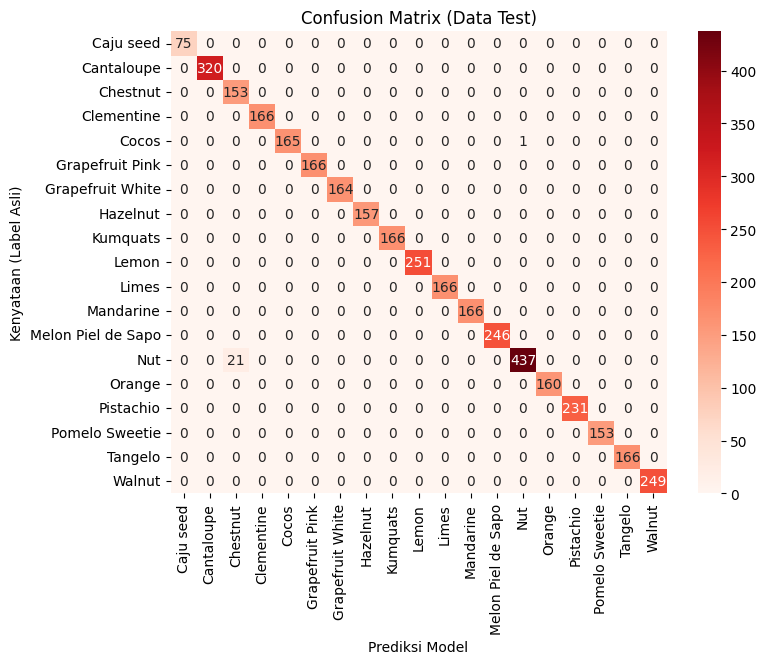

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Buat Confusion Matrix
cm = confusion_matrix(y_test_raw, y_pred_test)
labels = sorted(np.unique(y_test_raw)) # Mendapatkan nama kelas urut abjad

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan (Label Asli)')
plt.title('Confusion Matrix (Data Test)')
plt.show()

Dari hasil pemaparan predikti model dengan menggunakan Confusion Matrix didapatkan hasil sebagai berikut

- ada **21** gambar **Nut** yang salah prediksi menjadi **Chestnut**
- hanya ada **1** gambar **cocos** yang salah prediksi menjadi **nut**

hasil performansi model menggunakan grafik

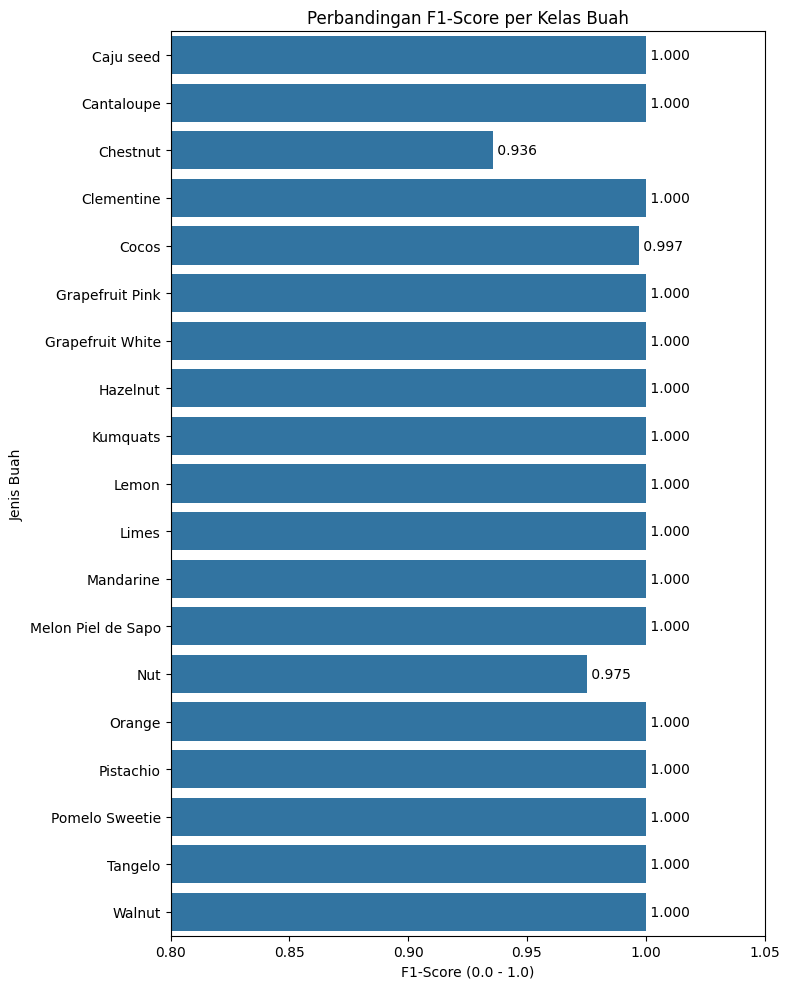

In [24]:
import pandas as pd

# Ambil data F1-Score per kelas dari report
class_names = []
f1_scores = []

for label in labels:
    class_names.append(label)
    f1_scores.append(report_dict[label]['f1-score'])

# Buat DataFrame biar gampang di-plot
df_perf = pd.DataFrame({
    'Kelas': class_names,
    'F1-Score': f1_scores
})

plt.figure(figsize=(8, 10)) # Ubah ukuran: Tinggi > Lebar biar muat ke bawah

# TUKAR X dan Y di sini
sns.barplot(x='F1-Score', y='Kelas', data=df_perf)

plt.xlim(0.8, 1.05) # Ganti ylim jadi xlim (karena sumbu skor sekarang di X)
plt.title('Perbandingan F1-Score per Kelas Buah')
plt.xlabel('F1-Score (0.0 - 1.0)')
plt.ylabel('Jenis Buah')

# Loop text untuk Horizontal Bar agak beda sedikit
for index, row in df_perf.iterrows():
    # Posisi text: (koordinat X, koordinat Y)
    # X = nilai skor, Y = index baris
    plt.text(row['F1-Score'], index, f" {row['F1-Score']:.3f}",
             color='black', va="center", ha="left") # ha="left" biar angka ada di kanan batang

plt.tight_layout()
plt.show()